# Figure 1 K-M: Freely moving augmented reality, system and performance

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-05-07 08:08:06,355::INFO::settings.py::Setting loglevel to INFO
2025-05-07 08:08:06,356::INFO::settings.py::Setting stores to {}
2025-05-07 08:08:06,357::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-05-07 08:08:06,357::INFO::settings.py::Setting database.misc.create_tables to True
2025-05-07 08:08:06,358::INFO::settings.py::Setting enable_python_native_blobs to True
2025-05-07 08:08:06,359::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-05-07 08:08:06,359::INFO::settings.py::Setting database.user to thomas
2025-05-07 08:08:06,360::INFO::settings.py::Setting database.password to thomas_mathislab


Connecting thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-05-07 08:08:06,656::INFO::connection.py::Connected thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
2025-05-07 08:08:06,769::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:07,219::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:07,219::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:07,910::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:07,910::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:08,073::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:08,073::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:08,424::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:08,424::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:08,756::INFO::table.py::could not log event in table ~log
2025-05-07 08:08:08,756::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema import dlc
from base_schemas.schemas import exp

style()

In [5]:
save_fig_path = "notebooks/Paper_figures/Figure_output/Figure1"
game_columns = ["dataset", "trial", "aperture", "trial_right_choice", "trial_left_choice", "reward", "iti", "x", "y", "trial_init_x", "trial_init_y", "trial_tortuosity", "trial_duration"]
dlc_columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle", "pose_time", "step_time","step"]

In [6]:
def get_all_in_list(data_set_list, training_stage, game_columns, dlc_columns):
    print(training_stage)
    big_df = []

    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)

        offline_kinematics_df = dlc.OfflineKinematics().get_data(
            key=d,
            columns=dlc_columns,
        )
        df = base_analysis.DataFrame().get_data(
            key=d,
            columns=game_columns,
        )
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)

        df = pd.concat([df, offline_kinematics_df], axis=1)

        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage

        big_df.append(df)

    big_df = pd.concat(big_df).reset_index()

    big_df["session_increment"] = (
        big_df.groupby("mouse_name")["dataset"]
        .rank(method="dense", ascending=True)
        .astype(int)
    )

    big_df = big_df.infer_objects()

    return big_df.reset_index(drop=True)

In [53]:
(vr4mice.Collab() & f'dataset = "{d}"').fetch("idx")

array([2])

In [ ]:
mouse_names = ["31726", "31726", "Jacana", "Kiwi", "Pheasant", "Oribi", "Nighingale", "Lemming", ""]
for m in mouse_names:
    for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
        training = (vr4mice.Dataset() & f'session_label = "{stage}" AND dataset LIKE "%{m}%"').fetch("dataset")
        for d in training:
            print(d)
            df = base_analysis.DataFrame().get_data(
            key={"dataset": d},
            columns=["dataset", "trial", "trial_duration"])
            df ["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key={"dataset": d})
            df ["lab_id"] = (vr4mice.Collab() & f'dataset = "{d}"').fetch("idx")[0]

31726_2025-02-06_1
31726_2025-02-07_1
31726_2025-02-10_1
31726_2025-02-11_1


In [8]:
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}"') & (
        vr4mice.Collab() & "idx=1"
    )
    training_list = [{"dataset": x["dataset"]} for x in training]
    print(training_list)
    #get_all_in_list(training_list, training_stage="training", game_columns=["dataset", "trial", "step", "trial_duration"], dlc_columns=["step"])

[{'dataset': 'Jacana_2024-07-28_1'}, {'dataset': 'Jacana_2024-07-29_2'}, {'dataset': 'Jacana_2024-07-30_1'}, {'dataset': 'Jacana_2024-07-31_1'}, {'dataset': 'Jacana_2024-08-01_1'}, {'dataset': 'Jacana_2024-08-02_1'}, {'dataset': 'Jacana_2024-08-05_2'}, {'dataset': 'Jacana_2024-08-06_1'}, {'dataset': 'Jacana_2024-08-07_1'}, {'dataset': 'Kiwi_2024-07-26_1'}, {'dataset': 'Kiwi_2024-07-27_1'}, {'dataset': 'Kiwi_2024-07-28_1'}, {'dataset': 'Kiwi_2024-07-29_1'}, {'dataset': 'Kiwi_2024-07-30_1'}, {'dataset': 'Kiwi_2024-07-31_1'}, {'dataset': 'Kiwi_2024-08-01_1'}, {'dataset': 'Oribi_2024-08-08_1'}, {'dataset': 'Oribi_2024-08-09_1'}, {'dataset': 'Oribi_2024-08-10_1'}, {'dataset': 'Oribi_2024-08-11_1'}, {'dataset': 'Oribi_2024-08-12_1'}, {'dataset': 'Pheasant_2024-08-08_1'}, {'dataset': 'Pheasant_2024-08-09_1'}, {'dataset': 'Pheasant_2024-08-10_1'}, {'dataset': 'Pheasant_2024-08-11_1'}]
[{'dataset': 'Jacana_2024-08-08_2'}, {'dataset': 'Kiwi_2024-08-02_1'}, {'dataset': 'Kiwi_2024-08-05_1'}, {'dat

In [ ]:
dfs = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}" AND dataset LIKE "%31726%"') & (
        vr4mice.Collab() & "idx=2"
    ) 
    training_list = [{"dataset": x["dataset"]} for x in training]
    if {"dataset": "Nightingale_2024-07-31_1"} in training_list:  # mathis lab
        training_list.remove({"dataset": "Nightingale_2024-07-31_1"})
    if {"dataset": "tom_2024-11-01_1"} in training_list:  # tolias lab
        training_list.remove({"dataset": "tom_2024-11-01_1"})
    dfs.append(get_all_in_list(data_set_list=training_list, training_stage=stage))
    
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}" AND dataset LIKE "%31728%"') & (
        vr4mice.Collab() & "idx=2"
    ) 
    training_list = [{"dataset": x["dataset"]} for x in training]
    if {"dataset": "Nightingale_2024-07-31_1"} in training_list:  # mathis lab
        training_list.remove({"dataset": "Nightingale_2024-07-31_1"})
    if {"dataset": "tom_2024-11-01_1"} in training_list:  # tolias lab
        training_list.remove({"dataset": "tom_2024-11-01_1"})
    dfs.append(get_all_in_list(data_set_list=training_list, training_stage=stage))



ar_detection_no_velthr
['31726', '2025-02-06', '1']


KeyboardInterrupt: 

In [ ]:
big_df = pd.concat(dfs).reset_index(drop=True)
big_df.to_pickle("big_df_contrast_training_tolias.pkl")

In [ ]:
dfs = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}"') & (
        vr4mice.Collab() & "idx=3"
    )
    training_list = [{"dataset": x["dataset"]} for x in training]
    if {"dataset": "Nightingale_2024-07-31_1"} in training_list:  # mathis lab
        training_list.remove({"dataset": "Nightingale_2024-07-31_1"})
    if {"dataset": "tom_2024-11-01_1"} in training_list:  # tolias lab
        training_list.remove({"dataset": "tom_2024-11-01_1"})
    dfs.append(get_all_in_list(data_set_list=training_list, training_stage=stage))

big_df = pd.concat(dfs).reset_index(drop=True)

ar_detection_no_velthr
['J729', '2024-11-09', '1']
['J729', '2024-11-10', '1']
['J729', '2024-11-11', '1']
['J729', '2024-11-12', '1']
['J729', '2024-11-13', '1']
['J729', '2024-11-14', '1']
['J729', '2024-11-15', '1']
['J729', '2024-11-16', '1']
['J729', '2024-11-17', '1']
['J731', '2024-11-09', '1']
['J731', '2024-11-10', '1']
['J731', '2024-11-11', '1']
['J731', '2024-11-12', '1']
['J731', '2024-11-13', '1']
['J731', '2024-11-14', '1']
['J731', '2024-11-15', '1']
['J731', '2024-11-16', '1']
['J731', '2024-11-17', '1']
ar_detection_velthr
['J729', '2024-11-18', '1']
['J729', '2024-11-19', '1']
['J729', '2024-11-20', '1']
['J729', '2024-11-21', '1']
['J729', '2024-11-22', '1']
['J729', '2024-11-23', '1']
['J731', '2024-11-18', '1']
['J731', '2024-11-19', '1']
['J731', '2024-11-20', '1']
['J731', '2024-11-21', '1']
['J731', '2024-11-22', '1']
['J731', '2024-11-23', '1']
['J731', '2024-11-27', '1']
['J731', '2024-11-28', '1']
ar_discrim
['J729', '2024-11-24', '1']
['J729', '2024-11-25',

In [ ]:
big_df.to_pickle("big_df_contrast_training_niell.pkl")

In [9]:
niell_data = pd.read_pickle("big_df_contrast_training_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_training_mathis.pkl")
tolias_data = pd.read_pickle("big_df_contrast_training_tolias.pkl")

big_df = pd.concat([niell_data, mathis_data, tolias_data]).reset_index(drop=True)

In [ ]:
def get_training_stage_per_mouse(big_df, mouse_name):
    new_df_list = []
    mouse_df = big_df[big_df.mouse_name == mouse_name].copy()

    df = mouse_df[(mouse_df.training_stage == "ar_detection_no_velthr")].copy()
    early = df[df.session_increment == df.session_increment.unique()[0]].copy()
    early["num_train_stage"] = 0
    new_df_list.append(early)

    mid = df[df.session_increment == df.session_increment.unique()[-1]].copy()  # -2
    mid["num_train_stage"] = 1
    new_df_list.append(mid)

    df = mouse_df[(mouse_df.training_stage == "ar_detection_velthr")].copy()
    late = df[df.session_increment == df.session_increment.unique()[-1]].copy()  # 0
    late["num_train_stage"] = 2
    new_df_list.append(late)

    df = mouse_df[(mouse_df.training_stage == "ar_discrim")].copy()

    early = df[df.session_increment == df.session_increment.unique()[0]].copy()
    early["num_train_stage"] = 3
    new_df_list.append(early)

    late = df[df.session_increment == df.session_increment.unique()[-1]].copy()  # 1
    late["num_train_stage"] = 5
    new_df_list.append(late)

    if len(df.session_increment.unique()) > 2:
        mid = df[df.session_increment == df.session_increment.unique()[-2]].copy()
        mid["num_train_stage"] = 4
        new_df_list.append(mid)
    return pd.concat(new_df_list)


def training_plots(
    big_df,
    mouse_name,
    variable,
    ax,
    ylim=(0, 1),
    midpoint_line=True,
    criterion_line=True,
    ylabel="Success rate/session",
    xlabel="Session",
    cmap=["#3FB47C", "#1F6F49", "#FF1493"],
    s=70,
):

    big_df = big_df.copy()
    big_df = big_df[big_df.mouse_name == mouse_name].copy()
    mean_mouse = big_df.groupby(
        ["mouse_name", "training_stage", "num_train_stage", "trial"], as_index=False
    ).mean(numeric_only=True)
    data = mean_mouse.groupby(
        ["mouse_name", "training_stage", "num_train_stage"], as_index=False
    ).mean(numeric_only=True)
    #print(mean_mouse [["mouse_name", "training_stage", "num_train_stage", "trial_duration"]])
    #data = mean_mouse[mean_mouse.mouse_name == mouse_name].copy()
    sns.lineplot(
        data=data,
        x="num_train_stage",
        y=variable,
        color="grey",
        legend=None,
        alpha=0.4,
        ax=ax,
        linewidth=1,
    )
    sns.scatterplot(
        data=data,
        x="num_train_stage",
        y=variable,
        hue="training_stage",
        palette=cmap,
        alpha=0.9,
        legend=None,
        zorder=100,
        s=s,
        ax=ax,
    )

    if variable == "trial_rewarded":
        ax.set_ylim(ylim[0], ylim[1])
        if midpoint_line:
            ax.axhline(0.5, linestyle="dashed", color="black", alpha=0.5)
        if criterion_line:
            ax.axhline(0.70, linestyle="dashed", color="red", alpha=0.3)
    if variable == "trial_count":
        ax.axhline(125, linestyle="dashed", color="red", alpha=0.3)

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    sns.despine(offset=10)
    return(data)


def days_in_training_stage(big_df, mouse_name):
    mean_mouse = big_df[big_df.mouse_name == mouse_name]
    mean_mouse = mean_mouse.groupby(["training_stage"], as_index=False)[
        "session"
    ].nunique()
    return mean_mouse

## Training task performance & training time

In [11]:
big_df = big_df[big_df.mouse_name != "Vegavis"]
big_df = big_df[big_df.dataset != "Nightingale_2024-07-31_2"]
big_df = big_df[big_df.dataset != "Kiwi_2024-08-08_3"]
big_df["session_increment"] = (
    big_df.groupby("mouse_name")["dataset"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# Mean plots

In [41]:
combined_training_df = []
for mouse_name in big_df.mouse_name.unique():
   tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
   combined_training_df.append(tmp_df)

In [42]:
mean_mouse = pd.concat(combined_training_df).groupby(
        ["mouse_name", "training_stage", "num_train_stage", "trial"], as_index=False
    ).mean(numeric_only=True)
mean_mouse = mean_mouse.groupby(
        ["mouse_name", "training_stage", "num_train_stage"], as_index=False
    ).mean(numeric_only=True)

In [46]:
session_df = mean_mouse[["mouse_name", "training_stage", "num_train_stage", "trial", "trial_rewarded", "trial_duration"]]

2025-05-07 08:37:49,140::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,140::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,149::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,149::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


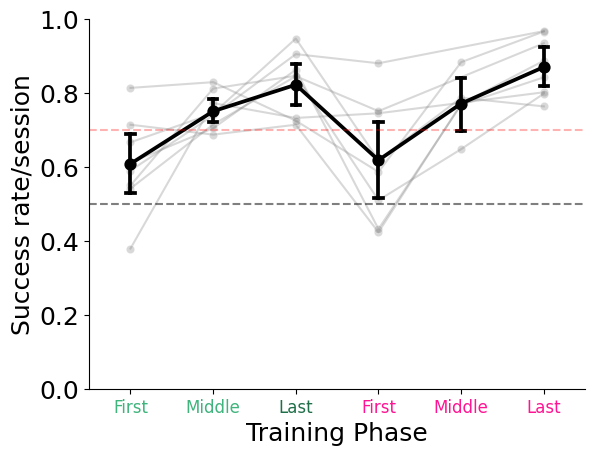

In [47]:
fig, ax = plt.subplots(1,1)
sns.lineplot(data = session_df, x="num_train_stage", y="trial_rewarded", units="mouse_name", estimator=None, marker="o", color="grey", zorder=0, alpha=.3)
sns.pointplot(data = session_df, x="num_train_stage", y="trial_rewarded", color="black", capsize=0.1)

ax.set_xlabel("Training Phase")
ax.set_ylabel("Success rate/session")
ax.set_ylim(0,1)
for i in range(1):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax.set_xticks(stage_positions)
    ax.set_xticklabels(stage_labels, rotation=0, fontsize=12)
    ax.axhline(0.5, linestyle="dashed", color="black", alpha=0.5)
    ax.axhline(0.70, linestyle="dashed", color="red", alpha=0.3)
    

    for j, label in enumerate(ax.get_xticklabels()):
        label.set_color(stage_colors[j])

2025-05-07 08:37:49,807::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,807::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,816::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,816::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


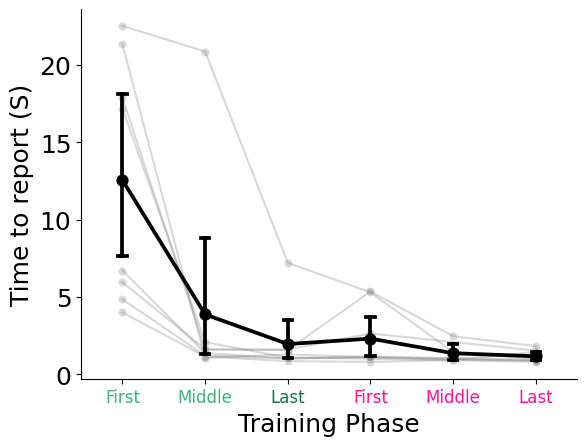

In [ ]:
fig, ax = plt.subplots(1,1)
sns.lineplot(data = session_df, x="num_train_stage", y="trial_duration", units="mouse_name", estimator=None, marker="o", color="grey", zorder=0, alpha=.3)
sns.pointplot(data = session_df, x="num_train_stage", y="trial_duration", color="black", capsize=0.1)

ax.set_xlabel("Training Phase")
ax.set_ylabel("Time to report (S)")
for i in range(2):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax.set_xticks(stage_positions)
    ax.set_xticklabels(stage_labels, rotation=0, fontsize=12)

    

    for j, label in enumerate(ax.get_xticklabels()):
        label.set_color(stage_colors[j])

# stats
Groups are unequal in number therefore use an Anova with Tuckey-HSD

In [91]:
import statsmodels.api as sm

from statsmodels.formula.api import ols
anova_rewarded = ols('trial_rewarded ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)



anova_rewarded = ols('trial_duration ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)

                   df    sum_sq   mean_sq         F   PR(>F)
num_train_stage   1.0  0.135800  0.135800  6.441947  0.01485
Residual         43.0  0.906465  0.021081       NaN      NaN
                   df       sum_sq     mean_sq          F    PR(>F)
num_train_stage   1.0   834.722386  834.722386  13.615028  0.000627
Residual         43.0  2636.282778   61.308902        NaN       NaN


In [93]:
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.trial_rewarded, session_df.num_train_stage, alpha=0.05)
results.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
0,1,0.166,0.0788,-0.0117,0.3436,False
0,2,0.231,0.0047,0.0534,0.4087,True
0,3,0.0039,1.0,-0.1738,0.1815,False
0,4,0.1988,0.057,-0.0038,0.4014,False
0,5,0.2517,0.0017,0.0741,0.4294,True
1,2,0.065,0.8796,-0.1126,0.2427,False
1,3,-0.1621,0.0911,-0.3398,0.0155,False
1,4,0.0328,0.9964,-0.1697,0.2354,False
1,5,0.0858,0.6992,-0.0919,0.2634,False
2,3,-0.2272,0.0056,-0.4048,-0.0495,True


In [94]:
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.trial_duration, session_df.num_train_stage, alpha=0.05)
results.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
0,1,-8.4807,0.2511,-19.9151,2.9536,False
0,2,-13.3416,0.0141,-24.776,-1.9072,True
0,3,-12.9245,0.0188,-24.3589,-1.4901,True
0,4,-14.0451,0.0283,-27.0823,-1.0079,True
0,5,-14.2415,0.0074,-25.6759,-2.8071,True
1,2,-4.8609,0.7972,-16.2953,6.5735,False
1,3,-4.4437,0.8508,-15.8781,6.9907,False
1,4,-5.5643,0.7946,-18.6015,7.4729,False
1,5,-5.7607,0.6604,-17.1951,5.6737,False
2,3,0.4171,1.0,-11.0173,11.8515,False


## Total training days

mean:  14.125 
sem:  2.1417407806334947


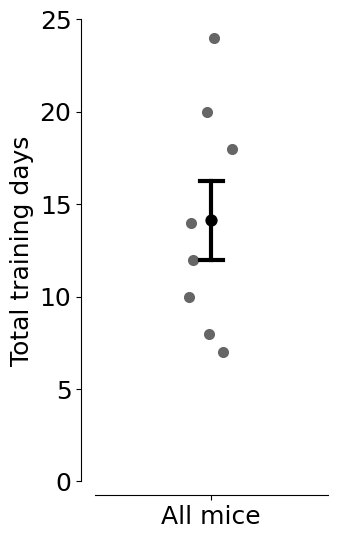

In [12]:
# Only training days
df = pd.DataFrame(big_df.groupby(["mouse_name"]).session_increment.nunique())
df["group"] = "mice"

plt.figure(figsize=(3, 6))
sns.stripplot(
    x="group",
    y="session_increment",
    data=df,
    color="black",
    jitter=True,
    size=8,
    alpha=0.6,
    zorder=1,
)
sns.pointplot(
    x="group",
    y="session_increment",
    data=df,
    join=False,
    color="black",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
)

plt.xticks([0], ["All mice"])
plt.xlabel("")

plt.ylabel("Total training days")
plt.ylim(0, 25)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure1_training_days.svg", transparent=True)

print(
    "mean: ",
    df.groupby("group")["session_increment"].mean().values[0],
    "\nsem: ",
    df.groupby("group")["session_increment"].sem().values[0],
)

2025-02-18 10:12:20,083::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,083::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,091::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,091::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,125::INFO::category.py::Using categorical un

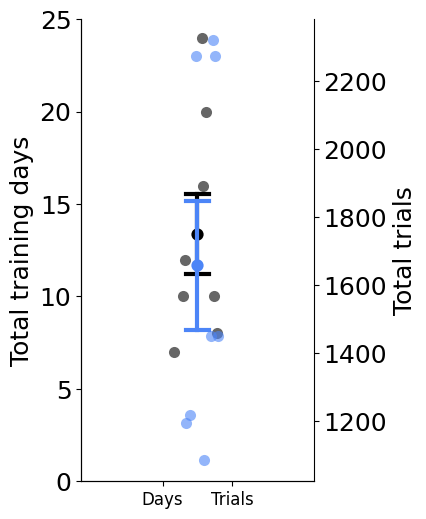

In [ ]:
# Training days and total trials
df = pd.DataFrame(big_df.groupby(["mouse_name"]).session_increment.nunique())
df_trials = pd.DataFrame(
    big_df.groupby(["mouse_name", "dataset"])
    .nunique()
    .groupby("mouse_name")
    .trial.sum()
)

df["group"] = "mice"
df_trials["group"] = "mice"
import numpy as np

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

offset = 0.15

fig, ax1 = plt.subplots(figsize=(3, 6))
sns.stripplot(
    x=np.full(len(df), -offset),
    y="session_increment",
    data=df,
    color="black",
    jitter=True,
    size=8,
    alpha=0.6,
    zorder=1,
    ax=ax1,
)

sns.pointplot(
    x=np.full(len(df), -offset),
    y="session_increment",
    data=df,
    join=False,
    color="black",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax1,
)

ax2 = ax1.twinx()
sns.stripplot(
    x=np.full(len(df_trials), offset),
    y="trial",
    data=df_trials,
    color="#4C85F7",
    jitter=True,
    size=8,
    alpha=0.6,
    zorder=3,
    ax=ax2,
)

sns.pointplot(
    x=np.full(len(df_trials), offset),
    y="trial",
    data=df_trials,
    join=False,
    color="#4C85F7",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=4,
    ax=ax2,
)

ax1.set_xticks([-offset, offset])
ax1.set_xticklabels(["Days", "Trials"], fontsize=12)
ax1.set_ylabel("Total training days")
ax1.set_ylim(0, 25)
ax1.spines["right"].set_visible(False)

ax2.set_ylabel("Total trials", color="k")
ax2.tick_params(axis="y", labelcolor="k")
ax2.spines["right"].set_visible(True)

plt.savefig(save_fig_path + "figure1_training_days_and_trials.svg", transparent=True)

In [ ]:
print(
    "mean: ",
    df.groupby("group")["session_increment"].mean().values[0],
    "\nsem: ",
    df.groupby("group")["session_increment"].sem().values[0],
)

print(
    "mean: ",
    df_trials.groupby("group")["trial"].mean().values[0],
    "\nsem: ",
    df_trials.groupby("group")["trial"].sem().values[0],
)

KeyError: 'group'

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
ax = ax.flatten()
combined_training_df = []
for (i, variable), ylabel in zip(
    enumerate(["trial_rewarded", "trial_duration"]),
    ["Success rate/session", "Time to report (s)"],
):
    for mouse_name in big_df.mouse_name.unique():
        tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
        data = training_plots(
            tmp_df, mouse_name=mouse_name, variable=variable, ax=ax[i], ylabel=ylabel
        )
        #print(tmp_df)
        #ax[i].set_ylim(0.0,1)
        combined_training_df.append(data)
    sns.despine(offset=10, ax=ax[i])

for i in range(2):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax[i].set_xticks(stage_positions)
    ax[i].set_xticklabels(stage_labels, rotation=0, fontsize=12)

    for j, label in enumerate(ax[i].get_xticklabels()):
        label.set_color(stage_colors[j])

    ax[i].figure.canvas.draw()

plt.savefig(save_fig_path + "figure1_training_success_and_time.svg", transparent=True)